## 1. Importações

In [11]:
# Manipulação de dados e álgebra linear
import pandas as pd
import numpy as np

# Visualização de resultados (Matriz de Confusão e Métricas)
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Divisão dos Dados
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Algoritmo de Classificação Baseline
from sklearn.linear_model import LogisticRegression

# Métricas de Avaliação de Modelagem
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve, 
    accuracy_score
)

# Ignorar avisos irrelevantes de atualizações de bibliotecas
import warnings
warnings.filterwarnings('ignore')

print("✅ Todas as bibliotecas essenciais foram importadas com sucesso!")

✅ Todas as bibliotecas essenciais foram importadas com sucesso!


## 2. Carregar Modelo

In [12]:
# Definindo o caminho do arquivo gerado no encerramento da AED
caminho_dados = '../data/processed/data_model/dados_model.csv'

# Lendo a base de dados
df_model = pd.read_csv(caminho_dados, sep=';')

print(f"✅ Dataset carregado com sucesso!")
print(f"Dimensões do dataframe: {df_model.shape[0]} linhas e {df_model.shape[1]} colunas.")

✅ Dataset carregado com sucesso!
Dimensões do dataframe: 208919 linhas e 29 colunas.


### 3. FEATURE ENGINEERING, SELEÇÃO DE X E Y

### 3.1 ENGENHARIA DE ATRIBUTOS: Criação da Variável 'turno'

In [13]:
df_model['hora_pura'] = pd.to_datetime(df_model['horario'], format='%H:%M:%S', errors='coerce').dt.hour

if df_model['hora_pura'].isnull().all():
    df_model['hora_pura'] = pd.to_datetime(df_model['horario'], format='%H:%M', errors='coerce').dt.hour

def categorizar_turno(hora):
    if 0 <= hora < 6: return 'Madrugada'
    elif 6 <= hora < 12: return 'Manhã'
    elif 12 <= hora < 18: return 'Tarde'
    else: return 'Noite'

df_model['turno'] = df_model['hora_pura'].apply(categorizar_turno)

### 3.2 SELEÇÃO DAS VARIÁVEIS EXPLÍCITAS (X) E ALVO (y)

In [14]:
# Adicionamos todas as variáveis de altíssimo impacto comportamental e físico
variaveis_explicitas = [
    'turno', 'condicao_metereologica', 'tracado_via', 'fase_dia', 
    'br', 'icm', 'icc', 'icp', 
    'tipo_pista', 'sentido_via', 'tipo_veiculo', 'sexo', 'dia_semana', 'uso_solo'
]

X_bruto = df_model[variaveis_explicitas]
y = df_model['acidente_grave_ou_fatal']

### 3.3. PREPARAÇÃO MATEMÁTICA: One-Hot Encoding (OHE)

In [15]:
colunas_categoricas = [
    'turno', 'condicao_metereologica', 'tracado_via', 'fase_dia', 
    'br', 'tipo_pista', 'sentido_via', 'tipo_veiculo', 'sexo', 'dia_semana', 'uso_solo'
]

X_final = pd.get_dummies(X_bruto, columns=colunas_categoricas, drop_first=True)

for col in X_final.columns:
    if X_final[col].dtype == 'bool':
        X_final[col] = X_final[col].astype(int)

print("--- Resumo da Nova Preparação dos Dados ---")
print(f"Total de registros: {len(y)}")
print(f"Formato final da matriz de recursos (X) com as novas variáveis: {X_final.shape}")

--- Resumo da Nova Preparação dos Dados ---
Total de registros: 208919
Formato final da matriz de recursos (X) com as novas variáveis: (208919, 724)


## 4. DIVISÃO EM TREINO/TESTE E PADRONIZAÇÃO

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, 
    y, 
    test_size=0.3, 
    random_state=42, 
    stratify=y  # Mantém a mesma proporção de gravidade nos dois conjuntos
)

# 4.2 Padronização apenas das colunas numéricas de infraestrutura
# As colunas geradas pelo One-Hot Encoding já estão na escala 0 e 1, portanto não devem ser alteradas.
colunas_numericas = ['icm', 'icc', 'icp']

scaler = StandardScaler()

# O ajuste (.fit_transform) é feito APENAS no treino para evitar vazamento de informação
X_train[colunas_numericas] = scaler.fit_transform(X_train[colunas_numericas])

# No conjunto de teste, apenas aplicamos a transformação (.transform) baseada no treino
X_test[colunas_numericas] = scaler.transform(X_test[colunas_numericas])

print("--- Resumo da Divisão dos Dados ---")
print(f"Registos de Treino (X_train): {X_train.shape[0]} linhas")
print(f"Registos de Teste (X_test): {X_test.shape[0]} linhas")
print("\n✅ Divisão e padronização concluídas com total segurança!")

--- Resumo da Divisão dos Dados ---
Registos de Treino (X_train): 146243 linhas
Registos de Teste (X_test): 62676 linhas

✅ Divisão e padronização concluídas com total segurança!


## 5. TREINAMENTO DO MODELO BASELINE

In [17]:
# Adicionamos class_weight='balanced' para punir o modelo se ele ignorar a classe minoritária
modelo_baseline = LogisticRegression(
    max_iter=1000, 
    random_state=42, 
    class_weight='balanced' # <-- A MÁGICA ESTÁ AQUI
)

# Treinando o modelo
modelo_baseline.fit(X_train, y_train)

print("✅ Modelo Baseline treinado com pesos balanceados!")

✅ Modelo Baseline treinado com pesos balanceados!


## 6. AVALIAÇÃO DO MODELO BASELINE

--- RELATÓRIO DE CLASSIFICAÇÃO ---
                     precision    recall  f1-score   support

0: Leve/Sem Vítimas       0.95      0.70      0.80     54545
     1: Grave/Fatal       0.27      0.74      0.39      8131

           accuracy                           0.70     62676
          macro avg       0.61      0.72      0.60     62676
       weighted avg       0.86      0.70      0.75     62676



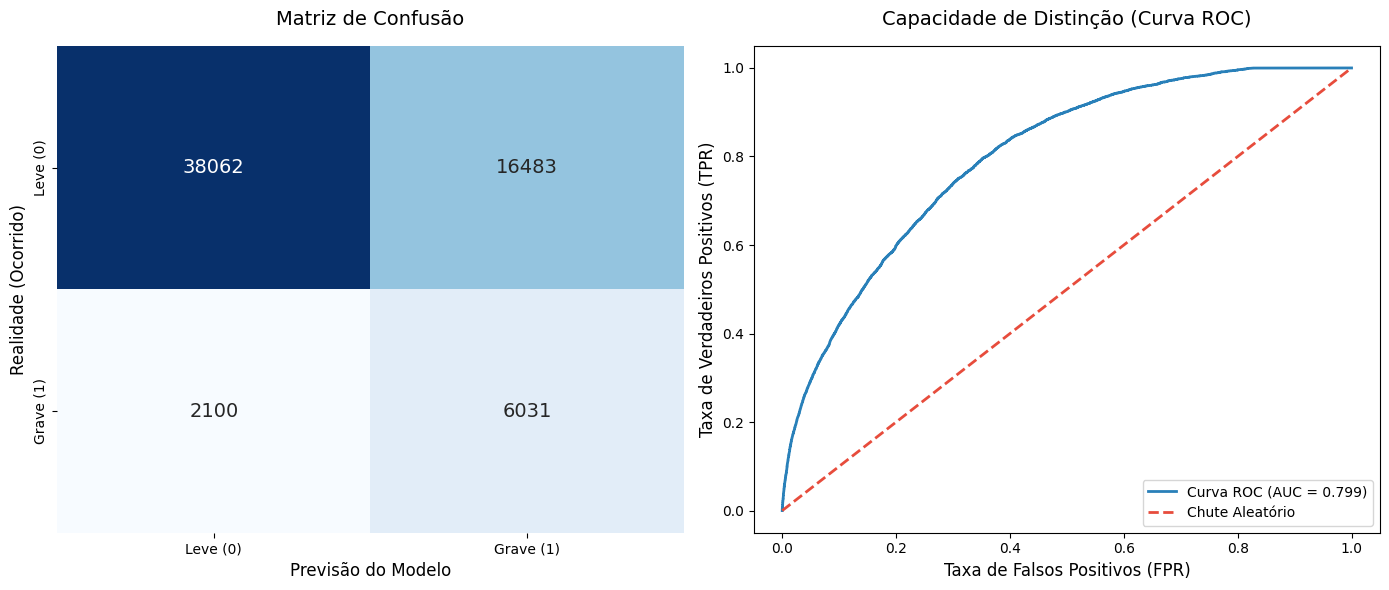

In [18]:
# 1. Realizando as Previsões
y_pred = modelo_baseline.predict(X_test)         # Previsão da classe (0 ou 1)
y_prob = modelo_baseline.predict_proba(X_test)[:, 1] # Probabilidade de ser classe 1 (0% a 100%)

# 2. Relatório de Métricas em Texto
print("--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred, target_names=['0: Leve/Sem Vítimas', '1: Grave/Fatal']))

# 3. Preparando os Gráficos (1x2)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- GRÁFICO 1: Matriz de Confusão ---
matriz = confusion_matrix(y_test, y_pred)
sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Leve (0)', 'Grave (1)'], 
            yticklabels=['Leve (0)', 'Grave (1)'],
            cbar=False, annot_kws={"size": 14})

axes[0].set_title('Matriz de Confusão', fontsize=14, pad=15)
axes[0].set_xlabel('Previsão do Modelo', fontsize=12)
axes[0].set_ylabel('Realidade (Ocorrido)', fontsize=12)

# --- GRÁFICO 2: Curva ROC e AUC ---
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

axes[1].plot(fpr, tpr, color='#2980b9', lw=2, label=f'Curva ROC (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='#e74c3c', lw=2, linestyle='--', label='Chute Aleatório')
axes[1].set_title('Capacidade de Distinção (Curva ROC)', fontsize=14, pad=15)
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

## 7. INTERPRETAÇÃO DO MODELO: O PESO DAS VARIÁVEIS (ODDS RATIO)


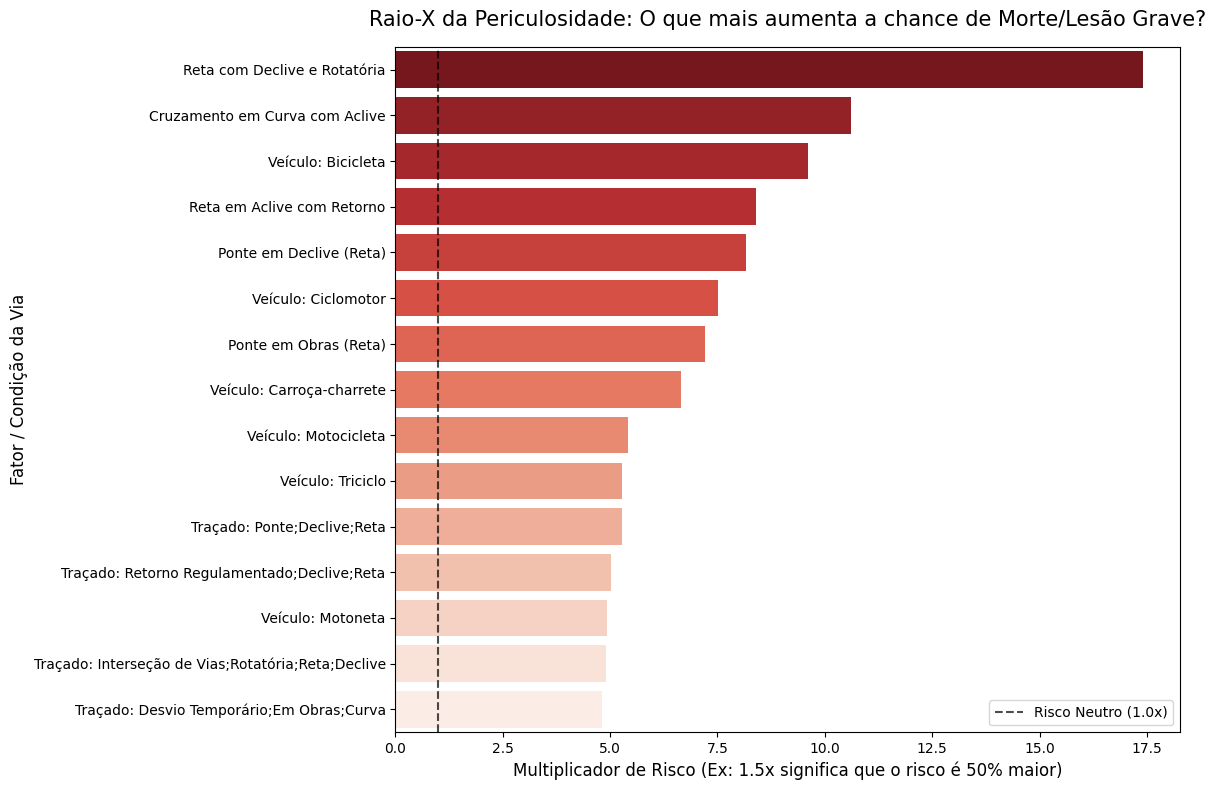

--- TOP 10 FATORES QUE MAIS AUMENTAM A PERICULOSIDADE DA VIA ---
                Variavel_Limpa  Multiplicador_Risco
  Reta com Declive e Rotatória            17.400010
Cruzamento em Curva com Aclive            10.612573
            Veículo: Bicicleta             9.604376
    Reta em Aclive com Retorno             8.406548
       Ponte em Declive (Reta)             8.155583
           Veículo: Ciclomotor             7.512634
         Ponte em Obras (Reta)             7.216146
     Veículo: Carroça-charrete             6.658245
          Veículo: Motocicleta             5.421755
             Veículo: Triciclo             5.278702


In [19]:
# ==========================================
# 7. INTERPRETAÇÃO DO MODELO: O PESO DAS VARIÁVEIS (ODDS RATIO)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extraindo os coeficientes e calculando o Odds Ratio (Multiplicador de Risco)
coeficientes = modelo_baseline.coef_[0]

# O np.exp transforma o coeficiente matemático puro em um multiplicador de probabilidade
odds_ratios = np.exp(coeficientes)

# 2. Criando um DataFrame para facilitar a visualização
df_importancia = pd.DataFrame({
    'Variavel': X_train.columns,
    'Coeficiente': coeficientes,
    'Multiplicador_Risco': odds_ratios
})

# --- SOLUÇÃO 1: FILTRANDO "NÃO INFORMADO" E "NAN" ---
# Removemos qualquer variável que contenha "Não Informado" ou "NaN". 
# Acidentes muito severos costumam ter dados faltando devido à destruição do veículo ou óbito no local.
df_importancia = df_importancia[~df_importancia['Variavel'].str.contains('Não Informado|NaN', case=False, na=False)]

# --- SOLUÇÃO 2: DICIONÁRIO E LIMPEZA DE NOMES ---
# Dicionário para traduções literais de categorias muito complexas
dicionario_nomes = {
    'tracado_via_Reta;Declive;Rotatória': 'Reta com Declive e Rotatória',
    'tracado_via_Interseção de Vias;Curva;Aclive': 'Cruzamento em Curva com Aclive',
    'tracado_via_Reta;Aclive;Retorno Regulamentado': 'Reta em Aclive com Retorno',
    'tracado_via_Reta;Declive;Ponte': 'Ponte em Declive (Reta)',
    'tracado_via_Reta;Ponte;Em Obras': 'Ponte em Obras (Reta)'
}

# Aplicando o dicionário
df_importancia['Variavel_Limpa'] = df_importancia['Variavel'].replace(dicionario_nomes)

# Limpeza automática dos prefixos do One-Hot Encoding para deixar o gráfico limpo
substituicoes_prefixos = {
    'tipo_veiculo_': 'Veículo: ',
    'tracado_via_': 'Traçado: ',
    'condicao_metereologica_': 'Clima: ',
    'fase_dia_': 'Luz: ',
    'turno_': 'Turno: ',
    'tipo_pista_': 'Pista: ',
    'sentido_via_': 'Sentido: ',
    'uso_solo_': 'Local: '
}

for prefixo, novo_nome in substituicoes_prefixos.items():
    df_importancia['Variavel_Limpa'] = df_importancia['Variavel_Limpa'].str.replace(prefixo, novo_nome)

# 3. Ordenando pelas variáveis que mais AUMENTAM o risco (Odds Ratio > 1)
df_importancia = df_importancia.sort_values(by='Multiplicador_Risco', ascending=False)

# 4. Plotagem dos 15 fatores mais impactantes para a Letalidade
plt.figure(figsize=(12, 8))
sns.barplot(
    data=df_importancia.head(15), 
    x='Multiplicador_Risco', 
    y='Variavel_Limpa', 
    palette='Reds_r' 
)

# Linha de referência (Odds Ratio = 1 significa que o fator não aumenta nem diminui o risco)
plt.axvline(x=1, color='black', linestyle='--', alpha=0.7, label='Risco Neutro (1.0x)')

plt.title('Raio-X da Periculosidade: O que mais aumenta a chance de Morte/Lesão Grave?', fontsize=15, pad=15)
plt.xlabel('Multiplicador de Risco (Ex: 1.5x significa que o risco é 50% maior)', fontsize=12)
plt.ylabel('Fator / Condição da Via', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

# 5. Exibindo o ranking em texto para o relatório
print("--- TOP 10 FATORES QUE MAIS AUMENTAM A PERICULOSIDADE DA VIA ---")
print(df_importancia.head(10)[['Variavel_Limpa', 'Multiplicador_Risco']].to_string(index=False))

In [20]:
import joblib
import os

# Criando uma pasta para salvar os modelos, se não existir
os.makedirs('../models', exist_ok=True)

# Salvando o modelo baseline treinado
joblib.dump(modelo_baseline, '../models/modelo_baseline.pkl')
print("✅ Modelo Baseline exportado com sucesso para '../models/modelo_baseline.pkl'!")

✅ Modelo Baseline exportado com sucesso para '../models/modelo_baseline.pkl'!


In [21]:
import joblib
# Salvando a lista de colunas que o modelo usou
joblib.dump(X_train.columns.tolist(), '../models/colunas_treino.pkl')

['../models/colunas_treino.pkl']